In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler,MinMaxScaler

2026-04-16 20:00:47.540557: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-16 20:00:48.008309: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 20:00:48.090670: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-16 20:00:49.286734: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

In [36]:
import numpy as np
n_splits=5
seq_length=44
# Load the data
data = np.load("/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data Augmentation/VAEs/time_vae_generated_data.npy")
feat_dim=17
# Inspect shape
print(data.shape)


(5000, 44, 17)


In [37]:
data=data[:, :, 1:]
y=data[:,:,0]

In [38]:
print(data.shape)

(5000, 44, 16)


In [39]:

data=data.reshape(data.shape[0],-1)
print(data.shape)

(5000, 704)


In [40]:
scaler=MinMaxScaler()
data=scaler.fit_transform(data)

In [41]:
data=data.reshape(data.shape[0],seq_length,16)
print(data.shape)

(5000, 44, 16)


In [8]:
n_splits=5
seq_length=45
df=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD001_cleaned.csv',sep=',')
test_df=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/FINAL transformer  PROJECT/data cleaning/test_FD001_cleaned.csv',sep=',')
df_time_warp=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data Augmentation/traditional techniques/time_warping_fd001.csv')
df_mag_warp=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data Augmentation/traditional techniques/magnitude_warping_fd001.csv')
df_scaling=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data Augmentation/traditional techniques/homogeneous_scaling_fd001.csv')
df_window=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data Augmentation/traditional techniques/window_permutation_fd001.csv')
rul_true=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/FINAL transformer  PROJECT/not ready datasets/not ready datasets/RUL_FD001.txt',header=None,names=["RUL"],sep=',')
feature_cols=[col for col in df.columns if not col in ['id','cycle','RUL','setting3']]

In [9]:
columns=['RUL' ,'cycle','setting1', 'setting2', 'setting3','sensor_2', 'sensor_3', 'sensor_4',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20',
       'sensor_21', 'id']
df=df[columns]
df_time_warp=df_time_warp[columns]
df_mag_warp=df_mag_warp[columns]
df_scaling=df_scaling[columns]
df_window=df_window[columns]

In [10]:
df_final = pd.concat(
    [df, df_time_warp, df_mag_warp, df_scaling,df_window],
    ignore_index=True
)

print(df_final.shape)

(103116, 20)


In [11]:
df_final['RUL']=df_final['RUL'].clip(upper=125)

In [12]:
def scaler_process(df,feature_cols):
    x=df[feature_cols]
    y=df['RUL']
    x_scaler=MinMaxScaler()
    x_scaled=x_scaler.fit_transform(x)
    indexes=df[feature_cols]
    scaled_df=pd.DataFrame(
        x_scaled,
        columns=feature_cols,
        index=indexes.index
    )
    scaled_df['cycle']=df['cycle']
    scaled_df['id']=df['id']
    y_clipped = y.clip(upper=125)
    scaled_df['RUL']=y_clipped/125.0
    
    return scaled_df , x_scaler

In [13]:
def scaler_test_process(df,scaler,feature_cols):

    x_scaled=scaler.transform(df[feature_cols])
    indexes=df[feature_cols]
    x_scaled=pd.DataFrame(
        x_scaled,
        columns=feature_cols,
        index=indexes.index
    )
    x_scaled['cycle']=df['cycle']
    x_scaled['id']=df['id']
    return x_scaled

In [14]:
def window_eng_sequences(df, seq_length, feature_cols):
    """
    Transforms a 2D dataframe into 3D array (Samples, Seq_Len, Features)
    using sliding window.
    """
    X, y = [], []

    for engine, engine_data in df.groupby('id'):
        if len(engine_data) < seq_length:
            continue
            
        engine_feat = engine_data[feature_cols].values
        engine_rul = engine_data['RUL'].values

        for i in range(len(engine_data) - seq_length + 1):
            X.append(engine_feat[i : i + seq_length])
            y.append(engine_rul[i + seq_length - 1])
            
    return np.array(X), np.array(y)

In [15]:
def gen_test_windows(df,seq_length, feature_cols,rul_true,RUL_MAX=125):
    X_test = []
    y_test = []

    for engine in df['id'].unique():
        engine_data = df[df['id'] == engine]

        if len(engine_data) >= seq_length:
            X_test.append(engine_data[feature_cols].values[-seq_length:])

            # CMAPSS ground truth is clipped & scaled
            rul = rul_true.loc[engine - 1].values[0]
            rul = min(rul, RUL_MAX) / RUL_MAX
            y_test.append(rul)

    return np.array(X_test), np.array(y_test)    

In [16]:
def evaluate_model(model, X_test, y_test_scaled, RUL_MAX=125):

    y_pred_scaled = model.predict(X_test)
    y_pred_scaled = y_pred_scaled

    y_pred = y_pred_scaled * RUL_MAX

    y_true = y_test_scaled * RUL_MAX
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("\nModel Performance Metrics (Original RUL scale):")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

    return y_pred, y_true

In [17]:
def plot_rf_importance(importances, feature_cols, seq_length=50):
    # The importance array is length (50 * 14)
    # We want to aggregate importance by SENSOR (summing across time)
    
    # Reshape back to (Time, Features)
    importance_matrix = importances.reshape(seq_length, len(feature_cols))
    
    # Sum across time axis -> Result shape (14,)
    sensor_importance = np.sum(importance_matrix, axis=0)
    
    # Create DataFrame
    imp_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': sensor_importance
    }).sort_values(by='Importance', ascending=False)
    
    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
    plt.title("Random Forest: Which Sensors Matter Most?")
    plt.xlabel("Aggregate Importance Score")
    plt.ylabel("Sensor Name")
    plt.grid(True, alpha=0.3)
    plt.show()

# Run this after training
# plot_rf_importance(importances, feature_cols, SEQ_LENGTH_RF)

In [42]:
RUL_MAX = 125
#df=df_final.copy()
df_scaled,scaler=scaler_process(df,feature_cols)
df_scaled.to_csv('df_scaled.csv',index=False)
common_cols=[col for col in df_scaled.columns if not col in ['RUL']]
test_df=test_df[common_cols]

In [43]:
print(df_scaled['RUL'])

0        1.000
1        1.000
2        1.000
3        1.000
4        1.000
         ...  
20626    0.032
20627    0.024
20628    0.016
20629    0.008
20630    0.000
Name: RUL, Length: 20631, dtype: float64


In [44]:
print(len(df_scaled.columns))


19


In [45]:
test_scaled_features=scaler_test_process(test_df,scaler,feature_cols)


In [46]:
print(len(test_scaled_features.columns))

18


In [47]:
test_scaled_df=test_scaled_features.copy()
id_col='id'
if id_col not in (test_scaled_df.columns):
    test_scaled_df['id'] = test_df['id'].values

In [60]:
seq_length=44
X_train,y_train=window_eng_sequences(df_scaled,seq_length,feature_cols)
#X_val,y_val=window_eng_sequences(val_df,seq_length,feature_cols)
X_test,y_test=gen_test_windows(test_scaled_df, seq_length, feature_cols, rul_true, RUL_MAX=125)

In [61]:
print(X_train.shape)
print(X_test.shape)

(16331, 44, 16)
(96, 44, 16)


In [62]:

X_train_aug = np.concatenate([X_train, data], axis=0)
  


In [63]:
# Reduce aug_y to one label per sample, e.g. the last timestep
aug_y_flat = y[:, -1]   # shape (5000,)

# Now both are 1-D
y_train_aug = np.concatenate([y_train, aug_y_flat], axis=0)
print(y_train_aug.shape)  # (21331,)



(21331,)


In [64]:
X_train_flat = X_train_aug.reshape(X_train_aug.shape[0], -1)
print(X_train_flat.shape)
print(y_train_aug.shape)


(21331, 704)
(21331,)


In [65]:
X_test_flat=X_test.reshape(X_test.shape[0],-1)

In [66]:
import xgboost as xgb
model = xgb.XGBRegressor(
                    n_estimators=300,       # Enough trees to learn
                    max_depth=5,            # Shallow depth prevents overfitting
                    learning_rate=0.05,     # Slow learning for better generalization
                    subsample=0.8,          # Use 80% of rows per tree
                    colsample_bytree=0.8,   # Use 80% of features per tree
                    objective='reg:squarederror',
                    n_jobs=-1,
                    random_state=42,

                )

In [67]:
print("Training XGB... (This might take a moment)")
model.fit(X_train_flat, y_train_aug)

Training XGB... (This might take a moment)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [68]:
y_pred, y_test=evaluate_model(model,X_test_flat , y_test, RUL_MAX=125)


Model Performance Metrics (Original RUL scale):
MSE:  175.7202
RMSE: 13.2560
MAE:  10.1679
R²:   0.8898


In [90]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import numpy as np

# Example dataset
# Convert to DMatrix (XGBoost’s optimized data structure)
dtrain = xgb.DMatrix(X_train_flat, label=y_train_aug)

# Set parameters
params = {

    "objective": "reg:squarederror",  # regression
    "eta": 0.01,                       # learning rate
    "max_depth": 5, 
    "min_child_weight": 5,                                   # tree depth
    "subsample": 0.8,                 # row sampling
    "colsample_bytree": 0.8  ,
    "random_state":42         # feature sampling
}

# Run cross-validation
cv_results = xgb.cv(
    params=params,
    dtrain=dtrain,
    num_boost_round=200,          # max boosting rounds
    nfold=5,                      # 5-fold CV
    metrics=["rmse"],             # evaluation metric
    early_stopping_rounds=10,     # stop if no improvement
    seed=42
)

print(cv_results.tail())



     train-rmse-mean  train-rmse-std  test-rmse-mean  test-rmse-std
195         0.136153        0.000284        0.142456       0.001206
196         0.135844        0.000291        0.142179       0.001208
197         0.135526        0.000284        0.141900       0.001221
198         0.135204        0.000280        0.141614       0.001224
199         0.134889        0.000281        0.141335       0.001224


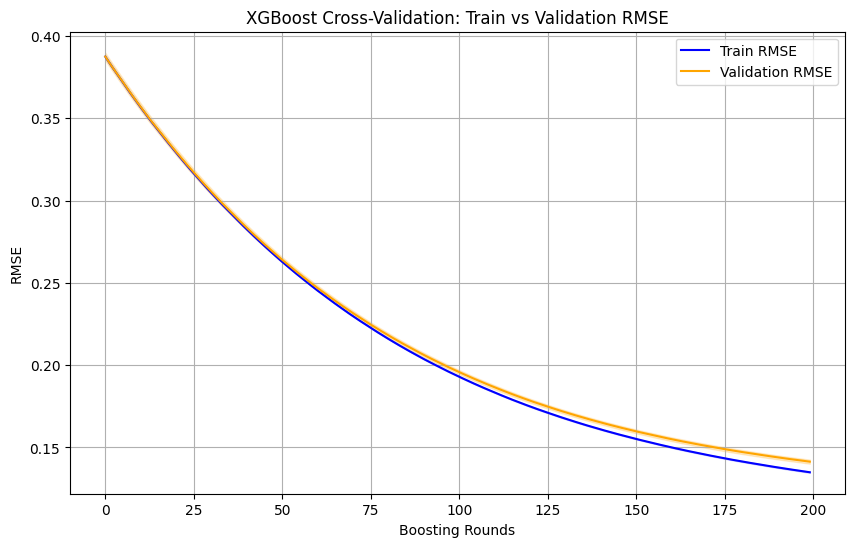

In [91]:
import matplotlib.pyplot as plt

# Suppose cv_results is your DataFrame from xgb.cv
# It has columns: 'train-rmse-mean', 'train-rmse-std', 'test-rmse-mean', 'test-rmse-std'

rounds = range(len(cv_results))

plt.figure(figsize=(10, 6))

# Plot train RMSE
plt.plot(rounds, cv_results['train-rmse-mean'], label='Train RMSE', color='blue')
plt.fill_between(
    rounds,
    cv_results['train-rmse-mean'] - cv_results['train-rmse-std'],
    cv_results['train-rmse-mean'] + cv_results['train-rmse-std'],
    color='blue',
    alpha=0.2
)

# Plot validation RMSE
plt.plot(rounds, cv_results['test-rmse-mean'], label='Validation RMSE', color='orange')
plt.fill_between(
    rounds,
    cv_results['test-rmse-mean'] - cv_results['test-rmse-std'],
    cv_results['test-rmse-mean'] + cv_results['test-rmse-std'],
    color='orange',
    alpha=0.2
)

plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.title("XGBoost Cross-Validation: Train vs Validation RMSE")
plt.legend()
plt.grid(True)
plt.show()


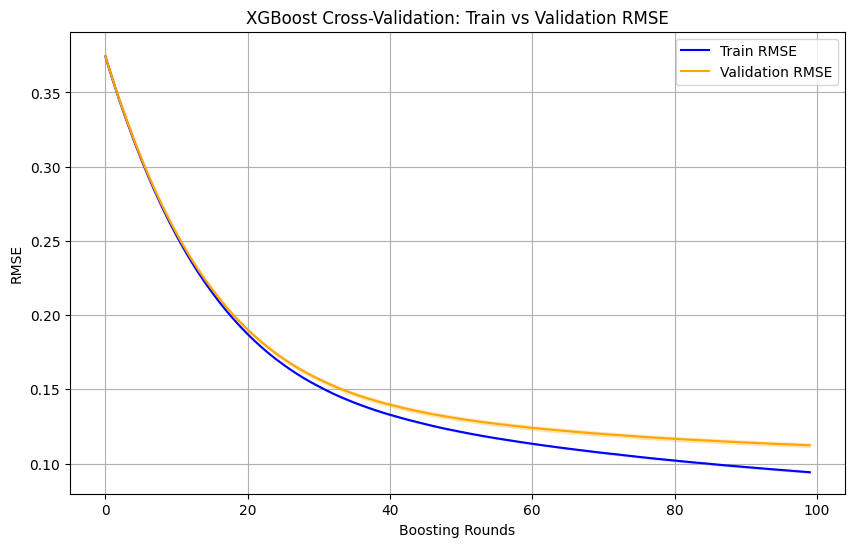

In [83]:
import matplotlib.pyplot as plt

# Assuming cv_results is your DataFrame from xgb.cv
rounds = range(len(cv_results))

plt.figure(figsize=(10, 6))

# Train RMSE curve
plt.plot(rounds, cv_results['train-rmse-mean'], label='Train RMSE', color='blue')
plt.fill_between(
    rounds,
    cv_results['train-rmse-mean'] - cv_results['train-rmse-std'],
    cv_results['train-rmse-mean'] + cv_results['train-rmse-std'],
    color='blue',
    alpha=0.2
)

# Validation RMSE curve
plt.plot(rounds, cv_results['test-rmse-mean'], label='Validation RMSE', color='orange')
plt.fill_between(
    rounds,
    cv_results['test-rmse-mean'] - cv_results['test-rmse-std'],
    cv_results['test-rmse-mean'] + cv_results['test-rmse-std'],
    color='orange',
    alpha=0.2
)

# Labels and title
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.title("XGBoost Cross-Validation: Train vs Validation RMSE")
plt.legend()
plt.grid(True)
plt.show()


In [57]:
# 1. Initialize counters OUTSIDE the loop
pessimistic_count = 0
optimistic_count = 0

# 2. Use zip() to pair the lists
for pred, act in zip(y_pred, y_test):
    
    # 3. Compare
    if pred < act:
        pessimistic_count += 1  # Use += to save the value
    else:
        optimistic_count += 1

# 4. Print results
print(f"Pessimistic predictions: {pessimistic_count}")
print(f"Optimistic predictions: {optimistic_count}")

if pessimistic_count > optimistic_count:
    print(" Verdict: Model is Pessimistic (Safer for Maintenance)")
else:
    print(" Verdict: Model is Optimistic (Risky for Maintenance)")

Pessimistic predictions: 48
Optimistic predictions: 48
 Verdict: Model is Optimistic (Risky for Maintenance)


In [45]:
import joblib 

joblib.dump(model, "RF_model_FD001.pkl")
joblib.dump(scaler,"RF_Scaler_FD001.pkl")

['RF_Scaler_FD001.pkl']